# Tarea 1 - IEE2714 - César Cossio Cornejo



Este Jupiter Notebok contiene los codigos de desarrollo de la Tarea 1 de curso IEE2714 Fundamentos de Procesamiento de Imágenes.

In [4]:
# Cargar carpeta con imagenes que usaremos para la tarea
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Pregunta 1 — Saturación selectiva de color


## Implementación

In [7]:
import skimage
from skimage import color
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from ipywidgets import interact, FloatSlider

In [8]:
# Interpolacion periodica
def interpolacion_periodica(h: float, puntos_control: list):
    # Se normaliza el tono
    h = h % 360

    # Se ordenan los puntos de control
    puntos = sorted(puntos_control, key=lambda p: p[0])

    # Se crean listas independientes de los valores de h y m
    h_es = [p[0] for p in puntos]
    m_es = [p[1] for p in puntos]

    # Se agrega el primer elemento trasladado en 360° para cumplir con
    # periodicidad
    h_es.append(h_es[0] + 360)
    m_es.append(m_es[0])

    # Se evalua si el valor a interpolar es menor que el primer valor de h_es
    if h < h_es[0]:
        h += 360

    # Se realiza la interpolación
    for i in range(len(h_es)-1):

        if h_es[i] <= h <= h_es[i+1]:

            t = (h-h_es[i])/(h_es[i+1]-h_es[i])

            return (1-t)*m_es[i] + t*m_es[i+1]

Para la funcion g_m se escogio una exponencial por sus propiedades, donde para valores de m entre [-1,1] se tiene que:

* m = 0 --> No cambia nada
* m > 0 --> Aumenta S/c*
* m < 0 --> Disminuye S/c*

In [9]:
# Función g_m
def gm(x, m, xmax = None):
    """
    x: componente original (S o c*)
    m: parámetro interpolado
    xmax: límite superior opcional
    """

    m = np.clip(m, -1, 1)
    y = x * np.exp(m)

    if xmax is not None:
        y = np.clip(y, 0, xmax)
    else:
        y = np.maximum(y, 0)

    return y

Funcion ColorSaturation.

Existen funciones de la libreria Skimage que sirven para tranformar desde el espacio RGB a HSV y RGB a Lab. Crearemos una funcion que pase de Lab a Lch.


In [10]:
def lab_to_lch(lab):

    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    c = np.sqrt(a**2 + b**2)

    h = np.degrees(np.arctan2(b, a))
    h = np.mod(h, 360)

    return L, c, h


def lch_to_lab(L, c, h):

    h_rad = np.radians(h)

    a = c * np.cos(h_rad)
    b = c * np.sin(h_rad)

    return np.dstack((L, a, b))

In [23]:
def ColorSaturation(image_rgb, puntos_control, mode="HSV"):

    mode = mode.upper()

    if mode == "HSV":

        hsv = color.rgb2hsv(image_rgb)

        H = hsv[:, :, 0] * 360
        S = hsv[:, :, 1]

        m_map = np.zeros_like(S)

        for i in range(S.shape[0]):
            for j in range(S.shape[1]):
                m_map[i, j] = interpolacion_periodica(H[i, j], puntos_control)

        hsv[:, :, 1] = gm(S, m_map, 1)

        return color.hsv2rgb(hsv)

    elif mode == "LCH":

        # RGB -> Lab
        lab = color.rgb2lab(image_rgb)

        # Lab -> LCh
        L, c, h = lab_to_lch(lab)

        m_map = np.zeros_like(c)

        for i in range(c.shape[0]):
            for j in range(c.shape[1]):
                m_map[i, j] = interpolacion_periodica(h[i, j], puntos_control)

        # Modificar únicamente el croma
        c_new = gm(c, m_map)

        # Volver a Lab
        lab_new = lch_to_lab(L, c_new, h)

        # Lab -> RGB
        rgb = color.lab2rgb(lab_new)

        return np.clip(rgb, 0, 1)

    else:
        raise ValueError("Modo debe ser 'HSV' o 'LCH'.")

## Experimentación y análisis

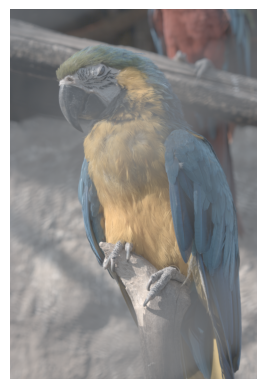

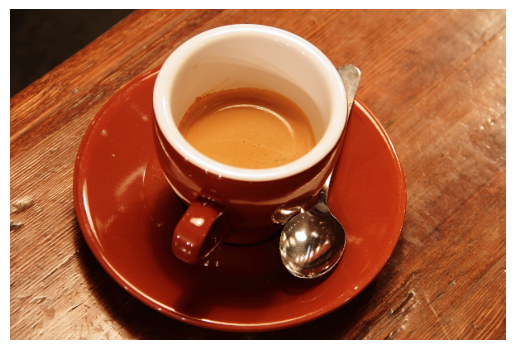

In [21]:
# Cargamos imagenes para aplicar las funciones creadas
ruta_1 = '/content/drive/MyDrive/IEE2714/ArchivosT1/P1_IMG_2402.tif'

imagen1 = cv2.imread(ruta_1)
imagen1_rgb = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

rgb_coffee = skimage.data.coffee()

plt.imshow(imagen1_rgb)
plt.axis('off')
plt.show()

plt.imshow(rgb_coffee)
plt.axis('off')
plt.show()

Probaremos 3 grupos de puntos de control:
* Uno que realza los amarillos
* Otro que atenua los rojos
* y Uno que combina los dos anteriores


In [19]:
# Realce de amarillos
control_yellow = [
    (20, 0.0),
    (45, 0.5),
    (60, 1.0),
    (75, 0.5),
    (100, 0.0)]
# Atenuación de rojos
control_red = [
    (300, 0.0),
    (330, -0.5),
    (350, -1.0),
    (20, -0.5),
    (60, 0.0)]
# Mezcla de realce y atenuacion
control_mix = [
    (330, -0.6),
    (30, -0.3),
    (60, 1.0),
    (90, 0.3),
    (150, 0.0)]

In [29]:
imagen1_rgb_copia = imagen1_rgb.copy()/255.0

imagen1_rgb_hsv_y = ColorSaturation(imagen1_rgb_copia, control_yellow, mode="HSV")
imagen1_rgb_lch_y = ColorSaturation(imagen1_rgb_copia, control_yellow, mode="LCH")

(np.float64(-0.5), np.float64(3463.5), np.float64(5201.5), np.float64(-0.5))

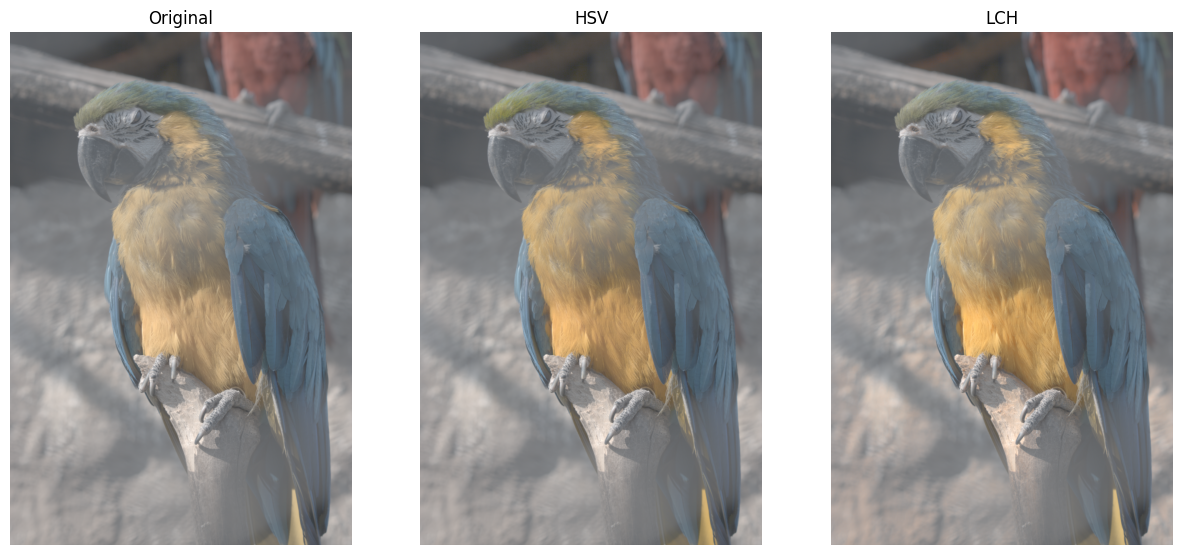

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

axes[0].imshow(imagen1_rgb, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(imagen1_rgb_hsv_y, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("HSV")
axes[1].axis("off")

axes[2].imshow(imagen1_rgb_lch_y, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("LCH")
axes[2].axis("off")

### Analisis
Se puede observar que en la tranformación LCH se observan los colores un poco mas vividos, tanto los amarillos como los rojos.

In [31]:
imagen1_rgb_hsv_r = ColorSaturation(imagen1_rgb_copia, control_red, mode="HSV")
imagen1_rgb_lch_r = ColorSaturation(imagen1_rgb_copia, control_red, mode="LCH")

(np.float64(-0.5), np.float64(3463.5), np.float64(5201.5), np.float64(-0.5))

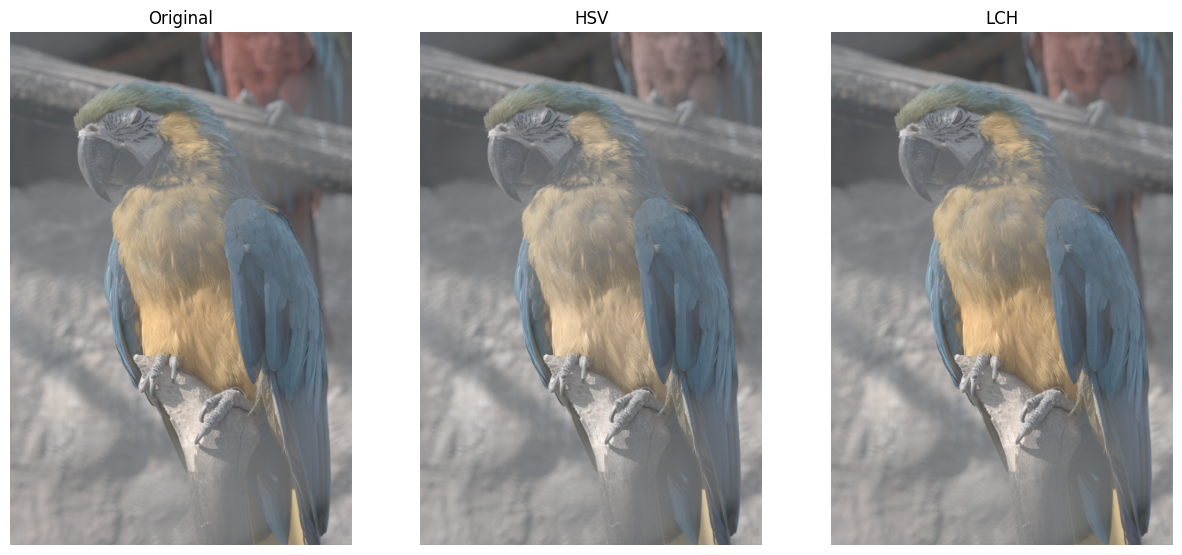

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

axes[0].imshow(imagen1_rgb, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(imagen1_rgb_hsv_r, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("HSV")
axes[1].axis("off")

axes[2].imshow(imagen1_rgb_lch_r, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("LCH")
axes[2].axis("off")

###Analisis
Se observa que la imagen HSV se atenua mas notablemente los colores rojos.

In [33]:
imagen1_rgb_hsv_m = ColorSaturation(imagen1_rgb_copia, control_red, mode="HSV")
imagen1_rgb_lch_m = ColorSaturation(imagen1_rgb_copia, control_red, mode="LCH")

(np.float64(-0.5), np.float64(3463.5), np.float64(5201.5), np.float64(-0.5))

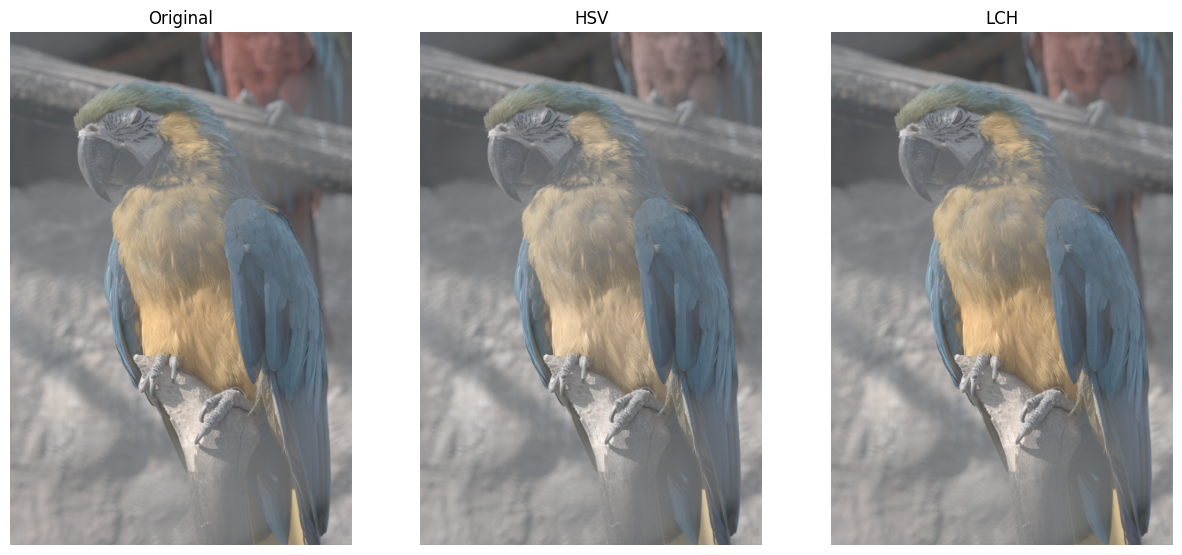

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

axes[0].imshow(imagen1_rgb, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(imagen1_rgb_hsv_m, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("HSV")
axes[1].axis("off")

axes[2].imshow(imagen1_rgb_lch_m, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("LCH")
axes[2].axis("off")